## Colab Setup

In [ ]:
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL  = "https://github.com/tackes/Modern-Time-Series-Forecasting-Cohort.git"
    REPO_PATH = "/content/packt-modern-time-series"

    if not os.path.exists(REPO_PATH):
        os.system(f"git clone -q {REPO_URL} {REPO_PATH}")

    # Stay in instructor_notebooks so Path().resolve().parent resolves to repo root
    os.chdir(f"{REPO_PATH}/instructor_notebooks")

    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)

    os.system("pip install -q statsforecast")

print(f"✓ Setup complete — {os.getcwd()}")

---
# Module 4 — Baselines & Modern Zero-Shot Benchmark
**Type:** [Code With Me / Instructor Demo]  
**Time:** 45 minutes  
**Job:** Establish the performance floor. Run Naive, SeasonalNaive, and AutoETS via StatsForecast cross-validation. Benchmark against `amazon/chronos-t5-mini`. Score everything and build the first leaderboard.


---
## 4.1 — Setup
**[Watch Only]**

---

In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS

from config import (
    ARTIFACT_DIR,
    WORKSHOP_SUBSET_PATH,
    HORIZON,
    SEASON_LENGTH,
    N_WINDOWS,
    STEP_SIZE,
    REFIT,
    MICRO_SUBSET_N,
    WORKSHOP_SUBSET_N,
    INTERVAL_COVERAGE,
    FM_DEMO_SERIES_N,
)
from src.checkpointing import load_checkpoint
from src.evaluation import score_forecasts
from src.schemas import validate_forecast, validate_score
from src.forecast_schema import reshape_statsforecast_cv
from src.plotting import plot_forecast_overlay, plot_metric_leaderboard

print("Setup complete.")

Setup complete.


---
## 4.2 — Load Panel and Build Micro Subset
**[Watch Only]**

---

In [15]:
# Load validated panel from Module 3 artifact
panel = load_checkpoint("03_validated_panel")

# Build micro subset — same selection rule as Module 3
top_series = (
    panel.groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(MICRO_SUBSET_N)
    .index
)
micro = panel[panel["unique_id"].isin(top_series)].copy()

print(f"Full panel : {panel['unique_id'].nunique():,} series")
print(f"Micro panel: {micro['unique_id'].nunique():,} series ({len(micro):,} rows)")


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 03_validated_panel
    File     : 03_validated_panel.parquet
    Rows     : 1,941,000

Full panel : 1,000 series
Micro panel: 50 series (97,050 rows)


---
## 4.3 — Why Baselines Matter
**[Watch Only]**


A baseline is not a warm-up exercise. It is a **build/don't-build decision threshold**.

- **Naive** — tomorrow = today. The absolute floor. Failing to beat it means something is wrong with your pipeline or evaluation setup.
- **SeasonalNaive** — next week = same day last week. Genuinely strong for weekly seasonal data. Zero training, zero infrastructure, zero maintenance.
- **AutoETS** — automatic exponential smoothing with model selection. The gold standard for univariate statistical forecasting at scale.
- **Chronos-t5-mini** — a zero-shot foundation model trained on billions of time series. Never saw your data. If your custom pipeline can't beat this, that's a signal worth taking seriously.

> Key idea: Every complex model must beat the best simpler alternative by enough to justify its added cost.

---
## 4.4 — Configure StatsForecast
**[Code With Me — 2 lines]**

Fill in `SeasonalNaive` and `AutoETS` with `season_length` from config. Do not hardcode the number.

---

In [16]:
# Configure StatsForecast with three baseline models
# Each model that accepts season_length gets it from config — no hardcoding

models = [
    Naive(),
    SeasonalNaive(season_length=SEASON_LENGTH),  # __FILL_IN__: pass season_length from config
    AutoETS(season_length=SEASON_LENGTH),        # __FILL_IN__: pass season_length from config
]

sf = StatsForecast(
    models=models,
    freq="D",
    n_jobs=-1,
)

print(f"StatsForecast configured with {len(models)} models:")
for m in models:
    print(f"  - {m}")

StatsForecast configured with 3 models:
  - Naive
  - SeasonalNaive
  - AutoETS


**Expected output:**
```
StatsForecast configured with 3 models:
  - Naive()
  - SeasonalNaive(season_length=7)
  - AutoETS(season_length=7)
```

---
## 4.5 — Run Cross-Validation on the Micro Subset
**[Watch Only]**

---

In [17]:
%%time
# Cross-validation on micro subset (50 series)
# Target runtime: < 45 seconds on Colab CPU

cv_micro = sf.cross_validation(
    df=micro,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=STEP_SIZE,
    refit=REFIT,
    level=[80],
)

print(f"CV complete: {cv_micro.shape[0]:,} rows × {cv_micro.shape[1]} columns")
cv_micro.head(3)

CV complete: 4,200 rows × 13 columns
CPU times: total: 93.8 ms
Wall time: 6.17 s


,unique_id,ds,cutoff,y,Naive,Naive-lo-80,Naive-hi-80,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-hi-80,AutoETS,AutoETS-lo-80,AutoETS-hi-80
0,FOODS_2_360_WI_2,2016-02-29,2016-02-28,0.0,0.0,-31.188845,31.188845,0.0,-48.940053,48.940053,7.602899e-41,-28.554216,28.554216
1,FOODS_2_360_WI_2,2016-03-01,2016-02-28,0.0,0.0,-44.107687,44.107687,0.0,-48.940053,48.940053,7.602899e-41,-32.429665,32.429665
2,FOODS_2_360_WI_2,2016-03-02,2016-02-28,0.0,0.0,-54.020664,54.020664,0.0,-48.940053,48.940053,7.602899e-41,-35.889039,35.889039


**Expected output:**
```
CV complete: 4,200 rows × 11 columns   # 50 series × 3 windows × 28 days
```

---
## 4.6 — Reshape to Forecast Schema
**[Watch Only]**

`reshape_statsforecast_cv` (from `src.forecast_schema`) converts the wide StatsForecast output — one column per model — into the workshop forecast schema: one row per model/window/step. The wide format was shown at the end of 4.5. Here we reshape and confirm the long format.

---

In [18]:
baseline_micro = reshape_statsforecast_cv(cv_micro, stage="baseline")

print(
    f"Reshaped forecasts: {baseline_micro.shape[0]:,} rows | "
    f"{baseline_micro['model'].nunique()} models"
)
baseline_micro.head(3)

Reshaped forecasts: 12,600 rows | 3 models


,unique_id,ds,y,model,y_hat,lo_80,hi_80,cutoff,stage
0,FOODS_2_360_WI_2,2016-02-29,0.0,Naive,0.0,0.0,31.188845,2016-02-28,baseline
1,FOODS_2_360_WI_2,2016-03-01,0.0,Naive,0.0,0.0,44.107687,2016-02-28,baseline
2,FOODS_2_360_WI_2,2016-03-02,0.0,Naive,0.0,0.0,54.020664,2016-02-28,baseline


**Expected output:**
```
Reshaped forecasts: (12600, 9)  # 4200 rows × 3 models
Models: ['Naive', 'SeasonalNaive', 'AutoETS']
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'y_hat', 'model', 'stage', 'lo_80', 'hi_80']
```

---
## 4.7 — Plot Baseline Forecasts
**[Watch Only]**

---

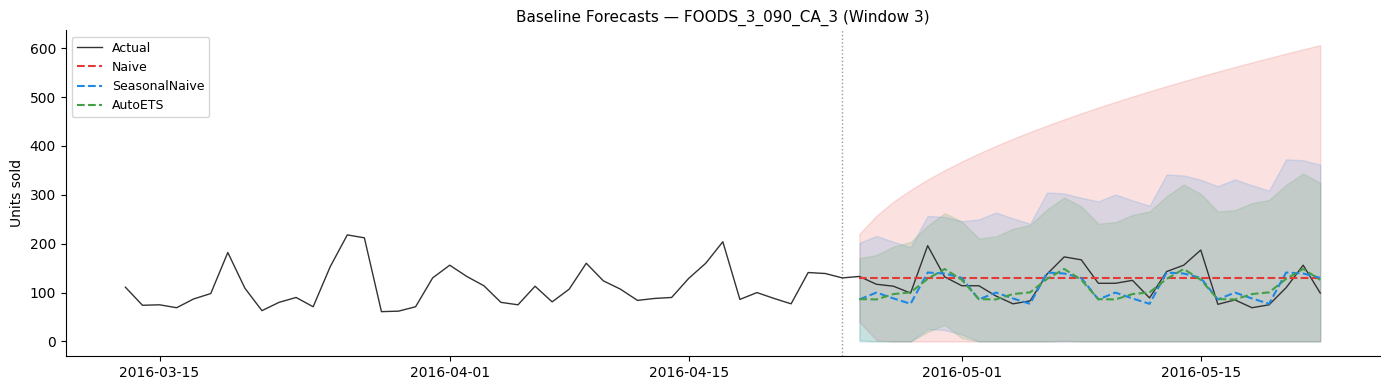

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'Baseline Forecasts — FOODS_3_090_CA_3 (Window 3)'}, ylabel='Units sold'>)

In [19]:
sample_uid = top_series[0]
sample_cut = baseline_micro["cutoff"].unique()[-1]  # most recent window

plot_forecast_overlay(
    actuals_df=panel,
    forecasts_df=baseline_micro,
    unique_id=sample_uid,
    cutoff=sample_cut,
    models=["Naive", "SeasonalNaive", "AutoETS"],
    title=f"Baseline Forecasts — {sample_uid} (Window 3)",
)

**Expected output:** A chart showing actual demand alongside three forecast lines from the cutoff date. SeasonalNaive should visually track the weekly pattern more closely than Naive.

---
## 4.8 — Chronos Live Demo
**[Watch Only]**


Chronos is a foundation model trained by Amazon on 1 billion time series observations. No training on your data — you hand it a context window and it produces a forecast distribution.

> Key idea: If a zero-shot model that has never seen your data is competitive with your custom pipeline, that's a signal worth taking seriously before investing in more infrastructure.

---

In [20]:
# If this cell errors or times out, jump to cell 4.9 (Red Path)

try:
    import torch
    from chronos import ChronosPipeline

    demo_ids = top_series[:FM_DEMO_SERIES_N]
    demo_cutoff = panel["ds"].max() - pd.Timedelta(days=STEP_SIZE)  # Window 3 cutoff

    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-mini",
        device_map="cpu",
        dtype=torch.float32,
    )

    demo_records = []
    for uid in demo_ids:
        context_series = panel[
            (panel["unique_id"] == uid) & (panel["ds"] <= demo_cutoff)
        ]["y"]
        context = torch.tensor(context_series.values, dtype=torch.float32).unsqueeze(0)

        forecast_tensor = pipeline.predict(
            context,
            prediction_length=HORIZON,
            num_samples=100,
            limit_prediction_length=False,
        )
        samples  = forecast_tensor[0].numpy()
        y_hat    = np.median(samples, axis=0)
        lo_80    = np.quantile(samples, 0.10, axis=0)
        hi_80    = np.quantile(samples, 0.90, axis=0)

        forecast_dates = pd.date_range(
            start=demo_cutoff + pd.Timedelta(days=1), periods=HORIZON, freq="D"
        )
        actuals = panel[
            (panel["unique_id"] == uid) & (panel["ds"].isin(forecast_dates))
        ][["ds", "y"]].set_index("ds")["y"].reindex(forecast_dates)

        for step_idx, (fdate, y_true) in enumerate(actuals.items()):
            if pd.isna(y_true):
                continue
            demo_records.append({
                "unique_id": uid,
                "ds":        fdate,
                "y":         float(y_true),
                "model":     "Chronos-t5-mini",
                "y_hat":     float(max(y_hat[step_idx], 0.0)),
                "lo_80":     float(max(lo_80[step_idx], 0.0)),
                "hi_80":     float(max(hi_80[step_idx], 0.0)),
                "cutoff":    demo_cutoff,
                "stage":     "baseline",
            })

    chronos_demo_df = pd.DataFrame(demo_records)
    print(f"Chronos demo complete: {len(chronos_demo_df)} rows across {FM_DEMO_SERIES_N} series")
    print(chronos_demo_df[["unique_id", "ds", "y", "y_hat", "lo_80", "hi_80"]].head(3).to_string())

except ImportError:
    print("Chronos not installed in this environment.")
    print("Install: pip install chronos-forecasting torch")
    print("Loading precomputed full-subset results instead (cell 4.9).")
    chronos_demo_df = None

Chronos demo complete: 84 rows across 3 series
          unique_id         ds      y       y_hat      lo_80       hi_80
0  FOODS_3_090_CA_3 2016-04-25  133.0  111.068695  85.884491  129.795425
1  FOODS_3_090_CA_3 2016-04-26  117.0   84.593040  68.707603  106.031868
2  FOODS_3_090_CA_3 2016-04-27  113.0   85.884491  70.903191  103.384308


---
## 4.9 — Load Precomputed Full-Subset Baselines
**[Watch Only]**

---

In [21]:
# 🔴 RED PATH (standard) — load precomputed full-subset baseline forecasts
# Covers Naive, SeasonalNaive, AutoETS, and Chronos-t5-mini

baseline_full = load_checkpoint("04_baseline_forecasts")

print(f"Baselines loaded: {len(baseline_full):,} rows — {sorted(baseline_full['model'].unique().tolist())}")


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 04_baseline_forecasts
    File     : 04_baseline_forecasts.parquet
    Rows     : 336,000

Baselines loaded: 336,000 rows — ['AutoETS', 'Chronos-t5-mini', 'Naive', 'SeasonalNaive']


**Expected output:**
```
Baselines loaded: 336,000 rows — ['AutoETS', 'Chronos-t5-mini', 'Naive', 'SeasonalNaive']
```

---
## 4.10 — Score the Baselines
**[Code With Me — 2 lines]**

Call `score_forecasts` on the full-subset artifact. Then load the precomputed CV scores checkpoint.

---

In [22]:
from src.evaluation import score_forecasts

baseline_scores    = score_forecasts(baseline_full, subset_name=f"workshop_{WORKSHOP_SUBSET_N}")  # __FILL_IN__: f"workshop_{WORKSHOP_SUBSET_N}"
baseline_cv_scores = load_checkpoint("04_baseline_cv_scores")                                     # __FILL_IN__: load_checkpoint("04_baseline_cv_scores")

wmape_scores = baseline_scores[baseline_scores["metric"] == "wMAPE"].sort_values("score")
print("Baseline wMAPE ranking:")
print(wmape_scores[["model", "score"]].to_string(index=False))


  ✓ RED PATH RECOVERY COMPLETE
    Artifact : 04_baseline_cv_scores
    File     : 04_baseline_cv_scores.parquet
    Rows     : 16

Baseline wMAPE ranking:
          model    score
        AutoETS 0.474567
Chronos-t5-mini 0.492306
  SeasonalNaive 0.558018
          Naive 0.665166


**Expected output (values will vary by subset):**
```
Baseline scores (wMAPE):
          model metric     score
        AutoETS  wMAPE  0.XXXX
  SeasonalNaive  wMAPE  0.XXXX
Chronos-t5-mini  wMAPE  0.XXXX
          Naive  wMAPE  0.XXXX
```

---
## 4.11 — Plot the Baseline Leaderboard
**[Watch Only]**

---

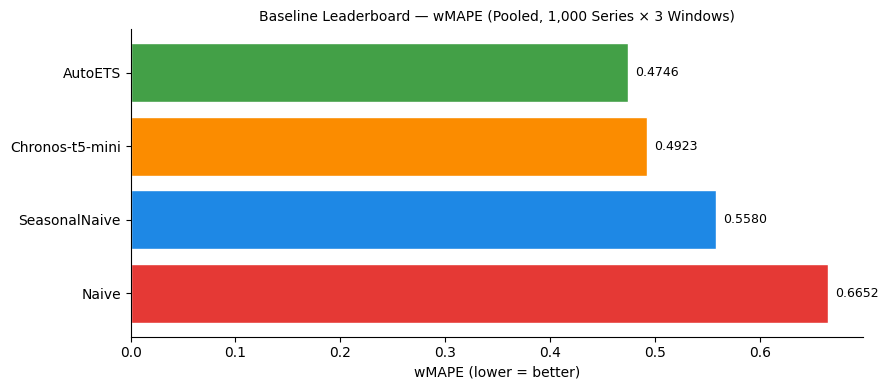

Best baseline : AutoETS — wMAPE = 0.4746
This is the floor. Every model in Modules 5 and 6 must beat this.


In [23]:
plot_metric_leaderboard(
    df=baseline_scores,
    metric="wMAPE",
    title="Baseline Leaderboard — wMAPE (Pooled, 1,000 Series × 3 Windows)",
)

best_baseline = baseline_scores[baseline_scores["metric"] == "wMAPE"].sort_values("score").iloc[0]
print(f"Best baseline : {best_baseline['model']} — wMAPE = {best_baseline['score']:.4f}")
print(f"This is the floor. Every model in Modules 5 and 6 must beat this.")

**Expected output:** Horizontal bar chart with four models ranked by wMAPE ascending. Green bar = best performing baseline.

---
## 4.12 — Save the Baseline Forecasts Artifact
**[Watch Only]**

---

In [24]:
# Validate and save live micro-subset results
baseline_micro_validated = validate_forecast(baseline_micro, artifact_name="04_baseline_micro")

micro_path = ARTIFACT_DIR / "04_baseline_micro_forecasts.parquet"
baseline_micro_validated.to_parquet(micro_path, index=False)
print(f"  ✓ Micro baseline saved : {micro_path.name} ({len(baseline_micro_validated):,} rows)")
print(f"  ✓ Full baseline loaded : 04_baseline_forecasts.parquet ({len(baseline_full):,} rows)")

  ✓ Micro baseline saved : 04_baseline_micro_forecasts.parquet (12,600 rows)
  ✓ Full baseline loaded : 04_baseline_forecasts.parquet (336,000 rows)
